# Automatic Speech Recognition (ASR) — Training v2

Dataset: Suara Bunga (10 Kelas, Mixed Gender)  
Pipeline Preprocessing (diperbarui):
1. Pre-Emphasis (0.97) — boost frekuensi tinggi  
2. Normalisasi Amplitudo  
3. Auto-Trim (buang keheningan)  
4. Bandpass Filter (300–3400 Hz)  
5. Notch Filter (50 Hz)  
6. Pad/Trim ke 2 detik  
7. Ekstraksi MFCC + Delta + Delta² (120 koef) + **CMVN**  

Model yang dilatih: **MLP**, **CNN-1D**, **SVM**, **HMM**

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from scipy.signal import butter, lfilter, iirnotch
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    Conv1D, MaxPooling1D, GlobalAveragePooling1D, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Install hmmlearn jika belum ada
try:
    from hmmlearn import hmm
except ImportError:
    os.system('pip install hmmlearn')
    from hmmlearn import hmm

warnings.filterwarnings('ignore')

# Cek GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'[INFO] {len(gpus)} GPU terdeteksi.')
else:
    print('[WARNING] Menggunakan CPU.')

[INFO] 1 GPU terdeteksi.


## 1. Konfigurasi Parameter


In [2]:
DATASET_PATH   = 'dataset'
MODEL_SAVE_PATH = 'models'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

SAMPLE_RATE = 16000
DURATION    = 2.0    # semua audio disamakan 2 detik
N_MFCC      = 40

CLASSES = sorted(['alamanda', 'anggrek', 'dahlia', 'krisan', 'lily',
                   'matahari', 'mawar', 'melati', 'teratai', 'tulip'])

print(f'Total kelas  : {len(CLASSES)}')
print(f'Sample Rate  : {SAMPLE_RATE} Hz')
print(f'Durasi audio : {DURATION} detik')

Total kelas  : 10
Sample Rate  : 16000 Hz
Durasi audio : 2.0 detik


## 2. Fungsi Preprocessing Audio
Pipeline: **Pre-Emphasis → Normalize → Auto-Trim → Bandpass → Notch → Pad/Trim**


In [3]:
def apply_preemphasis(y, coeff=0.97):
    """Boost frekuensi tinggi — memperjelas formant konsonan."""
    return np.append(y[0], y[1:] - coeff * y[:-1])

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq  = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return b, a

def apply_bandpass_filter(data, fs, lowcut=300.0, highcut=3400.0, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order)
    return lfilter(b, a, data)

def apply_notch_filter(data, fs, freq=50.0, q=30.0):
    nyq  = 0.5 * fs
    b, a = iirnotch(freq/nyq, q)
    return lfilter(b, a, data)

def preprocess_audio(file_path):
    """Pipeline preprocessing lengkap."""
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    y = apply_preemphasis(y)               # 1. Pre-emphasis
    y = librosa.util.normalize(y)          # 2. Normalisasi
    y, _ = librosa.effects.trim(y, top_db=30)  # 3. Auto-Trim
    y = apply_bandpass_filter(y, sr)       # 4. Bandpass
    y = apply_notch_filter(y, sr)          # 5. Notch
    max_len = int(SAMPLE_RATE * DURATION)
    if len(y) > max_len:
        y = y[:max_len]
    else:
        y = np.pad(y, (0, max_len - len(y)), mode='constant')
    return y, sr

## 3. Ekstraksi MFCC (dengan CMVN)


In [4]:
def extract_mfcc(y, sr=SAMPLE_RATE, n_mfcc=N_MFCC, return_sequence=False):
    """
    return_sequence=True  → CNN-1D & HMM : shape (TimeFrames, 120) + CMVN
    return_sequence=False → MLP & SVM    : shape (240,) = mean + std
    """
    mfcc        = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta_mfcc  = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    combined    = np.concatenate((mfcc, delta_mfcc, delta2_mfcc))  # (120, T)

    if return_sequence:
        seq = combined.T                                            # (T, 120)
        seq = (seq - seq.mean(axis=0)) / (seq.std(axis=0) + 1e-8) # CMVN
        return seq
    else:
        return np.concatenate((np.mean(combined, axis=1), np.std(combined, axis=1)))

## 4. Memuat Dataset


In [5]:
def load_and_extract_features():
    X_seq, X_flat, y_labels = [], [], []

    for label in CLASSES:
        folder = os.path.join(DATASET_PATH, label)
        if not os.path.exists(folder):
            continue
        files = glob.glob(os.path.join(folder, '*.wav'))
        print(f'  [{label}] {len(files)} file')

        for f in files:
            y_audio, sr = preprocess_audio(f)

            # Data asli (Tanpa augmentasi)
            X_seq.append(extract_mfcc(y_audio, return_sequence=True))
            X_flat.append(extract_mfcc(y_audio, return_sequence=False))
            y_labels.append(label)

    return np.array(X_seq), np.array(X_flat), np.array(y_labels)


print('Memuat dan mengekstrak fitur...')
X_seq, X_flat, y_labels = load_and_extract_features()
print(f'\nTotal sampel              : {len(y_labels)}')
print(f'Shape CNN/HMM (X_seq)     : {X_seq.shape}')
print(f'Shape MLP/SVM (X_flat)    : {X_flat.shape}')

Memuat dan mengekstrak fitur...
  [alamanda] 50 file
  [anggrek] 53 file
  [dahlia] 76 file
  [krisan] 84 file
  [lily] 75 file
  [matahari] 87 file
  [mawar] 70 file
  [melati] 101 file
  [teratai] 64 file
  [tulip] 55 file

Total sampel              : 715
Shape CNN/HMM (X_seq)     : (715, 63, 120)
Shape MLP/SVM (X_flat)    : (715, 240)


## 5. Split Data & Scaling


In [6]:
# Label Encoding
le        = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
y_cat     = tf.keras.utils.to_categorical(y_encoded, num_classes=len(CLASSES))
joblib.dump(le, os.path.join(MODEL_SAVE_PATH, 'label_encoder.pkl'))

# Split Flat (MLP, SVM)
X_train_flat, X_test_flat, y_train, y_test, y_train_cat, y_test_cat = train_test_split(
    X_flat, y_encoded, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)

# Split Sequential (CNN-1D, HMM)
X_train_seq, X_test_seq, _, _ = train_test_split(
    X_seq, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Label string untuk HMM
y_train_labels = le.inverse_transform(y_train)
y_test_labels  = le.inverse_transform(y_test)

# StandardScaler untuk fitur flat (MLP & SVM)
scaler       = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat  = scaler.transform(X_test_flat)
joblib.dump(scaler, os.path.join(MODEL_SAVE_PATH, 'scaler.pkl'))

print(f'Training : {X_train_flat.shape[0]} sampel')
print(f'Testing  : {X_test_flat.shape[0]} sampel')

Training : 572 sampel
Testing  : 143 sampel


## 6. Training & Evaluasi MLP


In [7]:
def build_mlp(input_shape):
    model = Sequential([
        Input(shape=(input_shape,)),
        Dense(512, activation='relu'), BatchNormalization(), Dropout(0.3),
        Dense(256, activation='relu'), BatchNormalization(), Dropout(0.3),
        Dense(128, activation='relu'), BatchNormalization(), Dropout(0.3),
        Dense(len(CLASSES), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

mlp = build_mlp(X_train_flat.shape[1])
callbacks_mlp = [
    EarlyStopping(patience=15, restore_best_weights=True),
    ModelCheckpoint(os.path.join(MODEL_SAVE_PATH, 'model_mlp.h5'), save_best_only=True),
    ReduceLROnPlateau(factor=0.5, patience=5)
]

print('Training MLP...')
hist_mlp = mlp.fit(
    X_train_flat, y_train_cat,
    validation_data=(X_test_flat, y_test_cat),
    epochs=100, batch_size=32, callbacks=callbacks_mlp, verbose=1
)

Training MLP...
Epoch 1/100
18/18 [==============================] - 4s 48ms/step - loss: 1.6784 - accuracy: 0.4808 - val_loss: 0.9112 - val_accuracy: 0.9161 - lr: 0.0010
Epoch 2/100
18/18 [==============================] - 0s 26ms/step - loss: 0.3724 - accuracy: 0.8986 - val_loss: 0.3834 - val_accuracy: 0.9790 - lr: 0.0010
Epoch 3/100
18/18 [==============================] - 0s 24ms/step - loss: 0.1498 - accuracy: 0.9720 - val_loss: 0.2063 - val_accuracy: 0.9860 - lr: 0.0010
Epoch 4/100
18/18 [==============================] - 0s 24ms/step - loss: 0.0897 - accuracy: 0.9913 - val_loss: 0.1231 - val_accuracy: 0.9930 - lr: 0.0010
Epoch 5/100
18/18 [==============================] - 0s 22ms/step - loss: 0.0636 - accuracy: 0.9930 - val_loss: 0.0771 - val_accuracy: 0.9930 - lr: 0.0010
Epoch 6/100
18/18 [==============================] - 0s 20ms/step - loss: 0.0648 - accuracy: 0.9860 - val_loss: 0.0499 - val_accuracy: 0.9930 - lr: 0.0010
Epoch 7/100
18/18 [==============================] - 0

Akurasi MLP: 100.00%
              precision    recall  f1-score   support

    alamanda       1.00      1.00      1.00        10
     anggrek       1.00      1.00      1.00        11
      dahlia       1.00      1.00      1.00        15
      krisan       1.00      1.00      1.00        17
        lily       1.00      1.00      1.00        15
    matahari       1.00      1.00      1.00        17
       mawar       1.00      1.00      1.00        14
      melati       1.00      1.00      1.00        20
     teratai       1.00      1.00      1.00        13
       tulip       1.00      1.00      1.00        11

    accuracy                           1.00       143
   macro avg       1.00      1.00      1.00       143
weighted avg       1.00      1.00      1.00       143



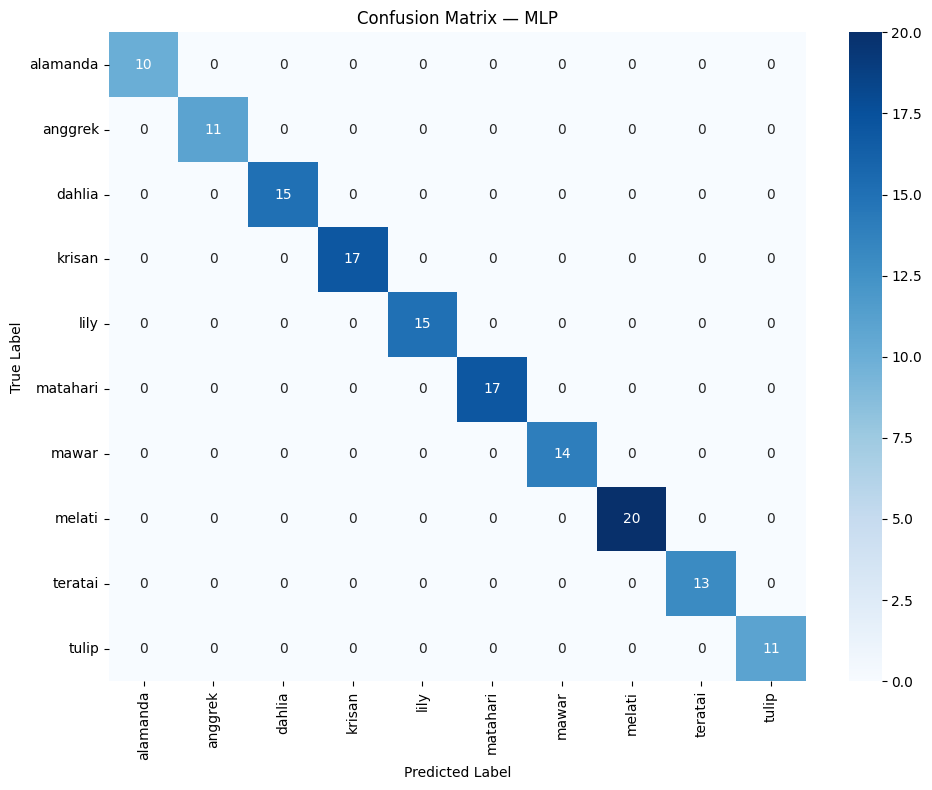

In [8]:
# Evaluasi MLP
y_pred_mlp = np.argmax(mlp.predict(X_test_flat, verbose=0), axis=1)
acc_mlp    = accuracy_score(y_test, y_pred_mlp)
print(f'Akurasi MLP: {acc_mlp*100:.2f}%')
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix — MLP')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 7. Training & Evaluasi CNN-1D


In [9]:
def build_cnn1d(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(), MaxPooling1D(pool_size=2), Dropout(0.3),
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(), MaxPooling1D(pool_size=2), Dropout(0.3),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(), GlobalAveragePooling1D(), Dropout(0.3),
        Dense(256, activation='relu'), Dropout(0.3),
        Dense(len(CLASSES), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn = build_cnn1d(X_train_seq.shape[1:])
callbacks_cnn = [
    EarlyStopping(patience=15, restore_best_weights=True),
    ModelCheckpoint(os.path.join(MODEL_SAVE_PATH, 'model_cnn1d.h5'), save_best_only=True),
    ReduceLROnPlateau(factor=0.5, patience=5)
]

print('Training CNN-1D...')
hist_cnn = cnn.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_test_seq, y_test_cat),
    epochs=100, batch_size=32, callbacks=callbacks_cnn, verbose=1
)

Training CNN-1D...
Epoch 1/100
18/18 [==============================] - 8s 47ms/step - loss: 2.0996 - accuracy: 0.3252 - val_loss: 2.1253 - val_accuracy: 0.2098 - lr: 0.0010
Epoch 2/100
18/18 [==============================] - 0s 24ms/step - loss: 1.2828 - accuracy: 0.7168 - val_loss: 1.5735 - val_accuracy: 0.5315 - lr: 0.0010
Epoch 3/100
18/18 [==============================] - 0s 24ms/step - loss: 0.4535 - accuracy: 0.9336 - val_loss: 0.9139 - val_accuracy: 0.7902 - lr: 0.0010
Epoch 4/100
18/18 [==============================] - 0s 23ms/step - loss: 0.1117 - accuracy: 0.9913 - val_loss: 0.4763 - val_accuracy: 0.9231 - lr: 0.0010
Epoch 5/100
18/18 [==============================] - 0s 25ms/step - loss: 0.0416 - accuracy: 0.9965 - val_loss: 0.1852 - val_accuracy: 0.9790 - lr: 0.0010
Epoch 6/100
18/18 [==============================] - 0s 23ms/step - loss: 0.0225 - accuracy: 0.9983 - val_loss: 0.1132 - val_accuracy: 0.9860 - lr: 0.0010
Epoch 7/100
18/18 [==============================] 

Akurasi CNN-1D: 100.00%
              precision    recall  f1-score   support

    alamanda       1.00      1.00      1.00        10
     anggrek       1.00      1.00      1.00        11
      dahlia       1.00      1.00      1.00        15
      krisan       1.00      1.00      1.00        17
        lily       1.00      1.00      1.00        15
    matahari       1.00      1.00      1.00        17
       mawar       1.00      1.00      1.00        14
      melati       1.00      1.00      1.00        20
     teratai       1.00      1.00      1.00        13
       tulip       1.00      1.00      1.00        11

    accuracy                           1.00       143
   macro avg       1.00      1.00      1.00       143
weighted avg       1.00      1.00      1.00       143



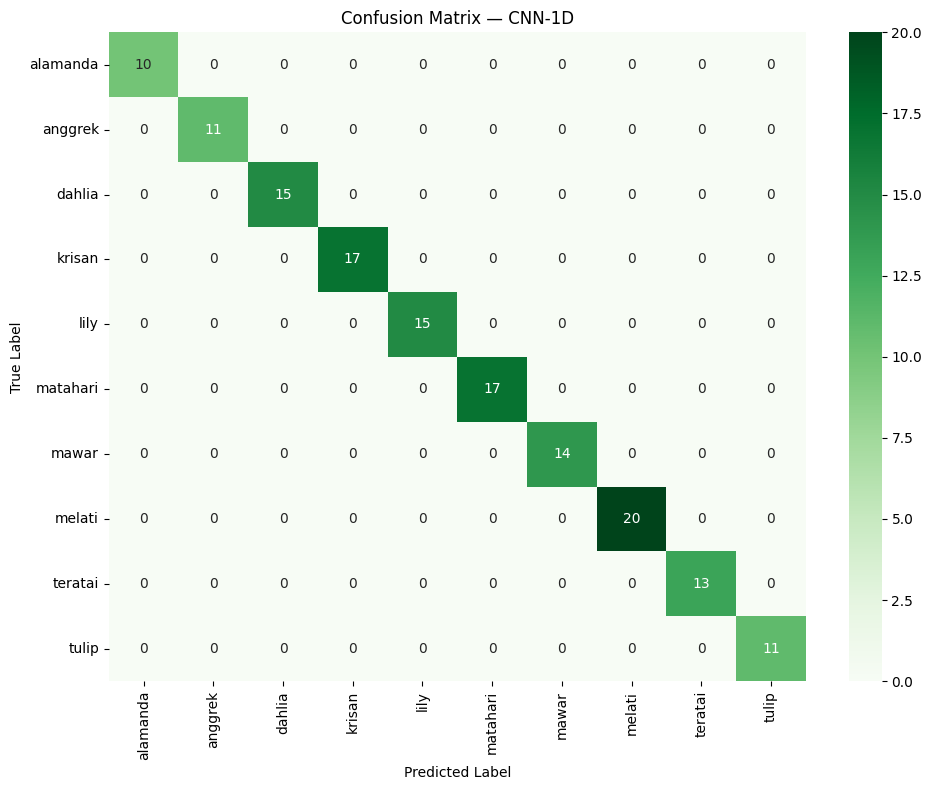

In [10]:
# Evaluasi CNN-1D
y_pred_cnn = np.argmax(cnn.predict(X_test_seq, verbose=0), axis=1)
acc_cnn    = accuracy_score(y_test, y_pred_cnn)
print(f'Akurasi CNN-1D: {acc_cnn*100:.2f}%')
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Greens')
plt.title('Confusion Matrix — CNN-1D')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 8. Training & Evaluasi SVM


Training SVM...
Akurasi SVM: 99.30%
              precision    recall  f1-score   support

    alamanda       0.91      1.00      0.95        10
     anggrek       1.00      0.91      0.95        11
      dahlia       1.00      1.00      1.00        15
      krisan       1.00      1.00      1.00        17
        lily       1.00      1.00      1.00        15
    matahari       1.00      1.00      1.00        17
       mawar       1.00      1.00      1.00        14
      melati       1.00      1.00      1.00        20
     teratai       1.00      1.00      1.00        13
       tulip       1.00      1.00      1.00        11

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



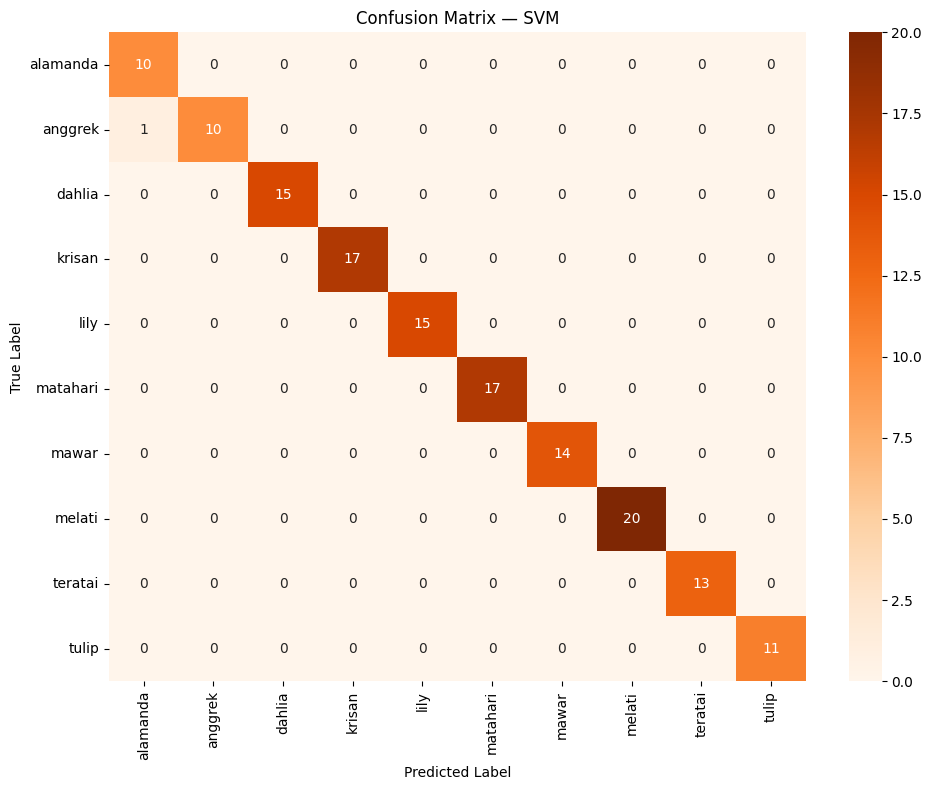

In [11]:
from sklearn.svm import SVC

print('Training SVM...')
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_flat, y_train)
joblib.dump(svm, os.path.join(MODEL_SAVE_PATH, 'model_svm.pkl'))

y_pred_svm = svm.predict(X_test_flat)
acc_svm    = accuracy_score(y_test, y_pred_svm)
print(f'Akurasi SVM: {acc_svm*100:.2f}%')
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Oranges')
plt.title('Confusion Matrix — SVM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 9. Training & Evaluasi HMM (Hidden Markov Model)
Setiap kelas bunga dimodelkan dengan satu GaussianHMM dengan **5 state**.  
Prediksi dilakukan dengan memilih HMM yang memberikan **log-likelihood tertinggi**.


In [12]:
from hmmlearn import hmm

print('Training HMM (1 model per kelas)...')
hmm_models = {}

for label in CLASSES:
    # Ambil seluruh sequence training untuk kelas ini
    idx       = [i for i, l in enumerate(y_train_labels) if l == label]
    sequences = [X_train_seq[i] for i in idx]

    X_concat = np.concatenate(sequences, axis=0)
    lengths  = [s.shape[0] for s in sequences]

    model = hmm.GaussianHMM(
        n_components=5,
        covariance_type='diag',
        n_iter=100,
        random_state=42
    )
    model.fit(X_concat, lengths)
    hmm_models[label] = model
    print(f'  [{label}] Selesai.')

joblib.dump(hmm_models, os.path.join(MODEL_SAVE_PATH, 'model_hmm.pkl'))
print('\nSemua model HMM tersimpan!')

Training HMM (1 model per kelas)...
  [alamanda] Selesai.
  [anggrek] Selesai.
  [dahlia] Selesai.
  [krisan] Selesai.
  [lily] Selesai.
  [matahari] Selesai.
  [mawar] Selesai.
  [melati] Selesai.
  [teratai] Selesai.
  [tulip] Selesai.

Semua model HMM tersimpan!


Evaluasi HMM pada test set...
Akurasi HMM: 98.60%
              precision    recall  f1-score   support

    alamanda       1.00      1.00      1.00        10
     anggrek       1.00      1.00      1.00        11
      dahlia       1.00      1.00      1.00        15
      krisan       1.00      0.94      0.97        17
        lily       0.94      1.00      0.97        15
    matahari       0.94      1.00      0.97        17
       mawar       1.00      1.00      1.00        14
      melati       1.00      0.95      0.97        20
     teratai       1.00      1.00      1.00        13
       tulip       1.00      1.00      1.00        11

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



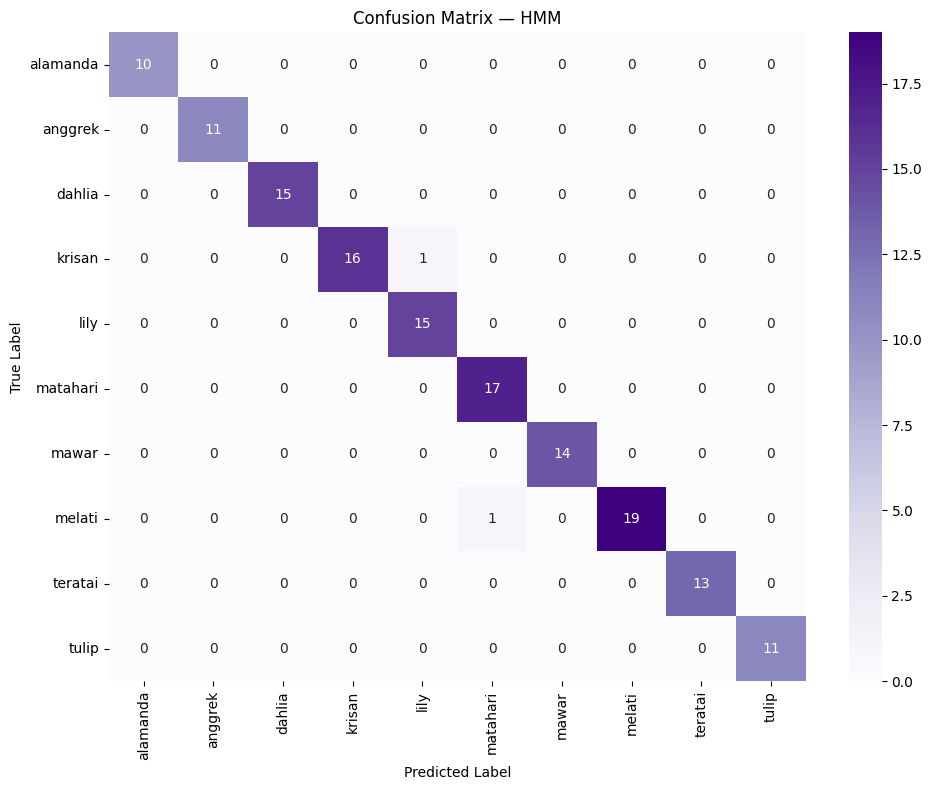

In [13]:
# Evaluasi HMM
def predict_hmm(hmm_models, sequence):
    scores = {}
    for label, model in hmm_models.items():
        try:    scores[label] = model.score(sequence)
        except: scores[label] = -np.inf
    return max(scores, key=scores.get)

print('Evaluasi HMM pada test set...')
y_pred_hmm = [predict_hmm(hmm_models, X_test_seq[i]) for i in range(len(X_test_seq))]
acc_hmm    = accuracy_score(y_test_labels, y_pred_hmm)
print(f'Akurasi HMM: {acc_hmm*100:.2f}%')
print(classification_report(y_test_labels, y_pred_hmm, target_names=le.classes_))

cm = confusion_matrix(y_test_labels, y_pred_hmm, labels=le.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Purples')
plt.title('Confusion Matrix — HMM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 10. Perbandingan Semua Model


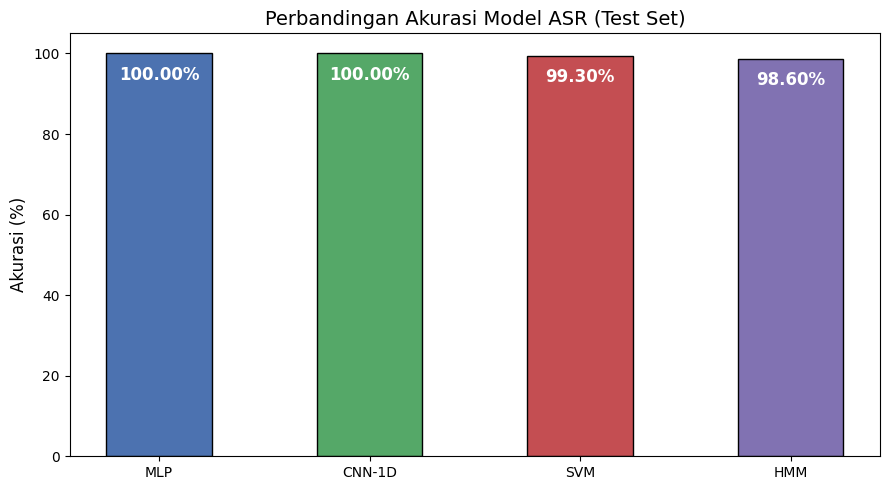


=== Ringkasan Akurasi ===
MLP     : 100.00%
CNN-1D  : 100.00%
SVM     : 99.30%
HMM     : 98.60%

Model terbaik: MLP (100.00%)


In [14]:
models_name = ['MLP', 'CNN-1D', 'SVM', 'HMM']
accuracies  = [acc_mlp * 100, acc_cnn * 100, acc_svm * 100, acc_hmm * 100]
colors      = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

plt.figure(figsize=(9, 5))
bars = plt.bar(models_name, accuracies, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
             f'{acc:.2f}%', ha='center', va='top', fontsize=12, color='white', fontweight='bold')
plt.ylim(0, 105)
plt.ylabel('Akurasi (%)', fontsize=12)
plt.title('Perbandingan Akurasi Model ASR (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

print('\n=== Ringkasan Akurasi ===')
for name, acc in zip(models_name, accuracies):
    print(f'{name:8s}: {acc:.2f}%')
best = models_name[int(np.argmax(accuracies))]
print(f'\nModel terbaik: {best} ({max(accuracies):.2f}%)')